In [1]:
# Core PyTorch utilities
!pip install -q torchinfo torchview torchmetrics graphviz

# System dependency for graphviz (needed for SVG rendering)
!apt-get install -y graphviz


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 47.3 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 53 not upgraded.


In [2]:
import os

KAGGLE_USERNAME = "icdar pytorch"
KAGGLE_KEY = "KGAT_b08f085f57433fcea05687ada681f387"

In [3]:
import os
os.environ["KAGGLE_USERNAME"] = "icdar pytorch"
os.environ["KAGGLE_KEY"] = "KGAT_b08f085f57433fcea05687ada681f387"

print("KAGGLE_USERNAME set:", "KAGGLE_USERNAME" in os.environ)
print("KAGGLE_KEY set:", "KAGGLE_KEY" in os.environ)


KAGGLE_USERNAME set: True
KAGGLE_KEY set: True


In [4]:
!pip install -q kaggle h5py torch torchvision torchmetrics tqdm seaborn matplotlib scikit-learn


In [5]:
import h5py
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from torchmetrics.classification import (
    MulticlassAccuracy,
    MulticlassPrecision,
    MulticlassRecall,
    MulticlassAUROC
)

from kaggle.api.kaggle_api_extended import KaggleApi

sns.set_style("darkgrid")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [6]:
from torchmetrics.classification import (
    MulticlassAccuracy,
    MulticlassPrecision,
    MulticlassRecall,
    MulticlassF1Score,
    MulticlassAUROC,
    MulticlassMatthewsCorrCoef
)
from torchinfo import summary
from torchview import draw_graph

In [7]:
import json
import os

os.makedirs("/root/.config/kaggle", exist_ok=True)

kaggle_json_path = "/root/.config/kaggle/kaggle.json"

with open(kaggle_json_path, "w") as f:
    json.dump({
        "username": os.environ["KAGGLE_USERNAME"],
        "key": os.environ["KAGGLE_KEY"]
    }, f)

os.chmod(kaggle_json_path, 0o600)

print("kaggle.json created at:", kaggle_json_path)


kaggle.json created at: /root/.config/kaggle/kaggle.json


In [8]:
import zipfile
import os

ZIP_PATH = "/content/Brain Tumor MRI Dataset (Glioma, Meningioma, Pitui.zip"
EXTRACT_DIR = "/content/mendeley_dataset"

os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Extraction complete.")

Extraction complete.


In [9]:
import zipfile
import os

for root, dirs, files in os.walk(EXTRACT_DIR):
    for file in files:
        if file.lower().endswith(".zip"):
            inner_zip = os.path.join(root, file)
            print("Extracting:", inner_zip)

            with zipfile.ZipFile(inner_zip, "r") as z:
                z.extractall(EXTRACT_DIR)

print("Finished extracting nested ZIPs.")

Extracting: /content/mendeley_dataset/Brain Tumor MRI Dataset (Glioma, Meningioma, Pitui/Epic and CSCR hospital Dataset.zip
Finished extracting nested ZIPs.


In [10]:
import os

for root, dirs, files in os.walk(EXTRACT_DIR):
    print(root)

/content/mendeley_dataset
/content/mendeley_dataset/Epic and CSCR hospital Dataset
/content/mendeley_dataset/Epic and CSCR hospital Dataset/Train
/content/mendeley_dataset/Epic and CSCR hospital Dataset/Train/meningioma
/content/mendeley_dataset/Epic and CSCR hospital Dataset/Train/glioma
/content/mendeley_dataset/Epic and CSCR hospital Dataset/Train/notumor
/content/mendeley_dataset/Epic and CSCR hospital Dataset/Train/pituitary
/content/mendeley_dataset/Epic and CSCR hospital Dataset/Test
/content/mendeley_dataset/Epic and CSCR hospital Dataset/Test/meningioma
/content/mendeley_dataset/Epic and CSCR hospital Dataset/Test/glioma
/content/mendeley_dataset/Epic and CSCR hospital Dataset/Test/notumor
/content/mendeley_dataset/Epic and CSCR hospital Dataset/Test/pituitary
/content/mendeley_dataset/Brain Tumor MRI Dataset (Glioma, Meningioma, Pitui


In [11]:
from pathlib import Path
import pandas as pd
import random

random.seed(42)

# Root of extracted dataset
ROOT = Path("/content/mendeley_dataset/Epic and CSCR hospital Dataset")

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

SAMPLES = {
    "glioma": 926,
    "meningioma": 937,
    "pituitary": 901,
    "notumor": 500,
}

def collect_images(folder, label):
    images = []

    if not folder.exists():
        print(f"Folder not found: {folder}")
        return images

    for img in folder.rglob("*"):
        if img.is_file() and img.suffix.lower() in IMAGE_EXTS:
            images.append({
                "image_path": str(img),
                "label": label
            })

    return images

# Collect all images
all_images = {}

for cls in SAMPLES.keys():

    imgs = []

    imgs.extend(
        collect_images(ROOT / "Train" / cls, cls)
    )

    imgs.extend(
        collect_images(ROOT / "Test" / cls, cls)
    )

    print(f"{cls:12s}: {len(imgs)} images found")

    random.shuffle(imgs)

    all_images[cls] = imgs[:SAMPLES[cls]]

# Combine
train_images = []
for cls in SAMPLES.keys():
    train_images.extend(all_images[cls])

# DataFrame
train_df = pd.DataFrame(train_images)

# Shuffle
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nCounts after sampling:")
print(train_df["label"].value_counts())

print("\nTotal images:", len(train_df))

train_df.head()

glioma      : 3773 images found
meningioma  : 2729 images found
pituitary   : 3130 images found
notumor     : 2432 images found

Counts after sampling:
label
meningioma    937
glioma        926
pituitary     901
notumor       500
Name: count, dtype: int64

Total images: 3264


,image_path,label
0,/content/mendeley_dataset/Epic and CSCR hospit...,meningioma
1,/content/mendeley_dataset/Epic and CSCR hospit...,glioma
2,/content/mendeley_dataset/Epic and CSCR hospit...,glioma
3,/content/mendeley_dataset/Epic and CSCR hospit...,glioma
4,/content/mendeley_dataset/Epic and CSCR hospit...,glioma


In [12]:
from sklearn.model_selection import train_test_split

# First split: 80% train, 20% temp
train_df, temp_df = train_test_split(
    train_df,
    test_size=0.20,
    stratify=train_df["label"],
    random_state=42
)

# Second split: temp -> 10% validation + 10% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(len(train_df), len(val_df), len(test_df))

2611 326 327


In [13]:
label_to_index = {
    "glioma": 0,
    "meningioma": 1,
    "pituitary": 2,
    "notumor": 3
}

In [15]:
label_map = {
    "glioma": 0,
    "meningioma": 1,
    "pituitary": 2,
    "notumor": 3,
}

train_df["label"] = train_df["label"].map(label_map)
val_df["label"] = val_df["label"].map(label_map)

# Only if test_df exists
if "test_df" in globals():
    test_df["label"] = test_df["label"].map(label_map)

num_classes = len(label_map)

print(train_df.head())

                                          image_path  label
0  /content/mendeley_dataset/Epic and CSCR hospit...      0
1  /content/mendeley_dataset/Epic and CSCR hospit...      1
2  /content/mendeley_dataset/Epic and CSCR hospit...      0
3  /content/mendeley_dataset/Epic and CSCR hospit...      2
4  /content/mendeley_dataset/Epic and CSCR hospit...      0


In [16]:
from PIL import Image

class BrainTumorDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "image_path"]
        label = self.df.loc[idx, "label"]

        img = Image.open(img_path).convert("RGB")
        img = self.transform(img)

        return img, label


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_loader = DataLoader(
    BrainTumorDataset(train_df, transform),
    batch_size=8,
    shuffle=True
)

val_loader = DataLoader(
    BrainTumorDataset(val_df, transform),
    batch_size=8
)

test_loader = DataLoader(
    BrainTumorDataset(test_df, transform),
    batch_size=8
)



In [17]:
def apply_avg_2max_pool_to_image(img_tensor, pool_layer):
    """
    img_tensor: torch.Tensor of shape (3, H, W)
    returns pooled image resized back to original size
    """
    img = img_tensor.unsqueeze(0)  # (1, 3, H, W)

    pooled_channels = []
    for c in range(3):
        ch = img[:, c:c+1, :, :]          # (1,1,H,W)
        pooled = pool_layer(ch)           # downsampled
        pooled = torch.nn.functional.interpolate(
            pooled, size=img.shape[-2:], mode="bilinear", align_corners=False
        )
        pooled_channels.append(pooled)

    pooled_img = torch.cat(pooled_channels, dim=1)
    return pooled_img.squeeze(0)


In [18]:
def visualize_original_vs_pooled(dataset, pool_layer, num_images=3):
    """
    Shows:
    Top row    -> Original images
    Bottom row -> Avg − 2×Max pooled images
    """
    indices = random.sample(range(len(dataset)), num_images)

    plt.figure(figsize=(4 * num_images, 6))

    for i, idx in enumerate(indices):
        img, _ = dataset[idx]  # img: (3,224,224)

        pooled_img = apply_avg_2max_pool_to_image(img, pool_layer)

        # Convert to display format
        orig = img.permute(1, 2, 0).cpu().numpy()
        pooled = pooled_img.permute(1, 2, 0).cpu().numpy()

        # Normalize for display
        orig = (orig - orig.min()) / (orig.max() - orig.min() + 1e-8)
        pooled = (pooled - pooled.min()) / (pooled.max() - pooled.min() + 1e-8)

        # ---- ORIGINAL ----
        plt.subplot(2, num_images, i + 1)
        plt.imshow(orig, cmap="gray")
        plt.title("Original")
        plt.axis("off")

        # ---- POOLED ----
        plt.subplot(2, num_images, i + 1 + num_images)
        plt.imshow(pooled, cmap="gray")
        plt.title("Avg − 2×Max pooled")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


In [19]:
import torch
import torch.nn as nn

class AvgTwiceMaxPooling2D(nn.Module):
    def __init__(self):
        super().__init__()
        self.avg = nn.AvgPool2d(kernel_size=3, stride=2, padding=1)
        self.max = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

    def forward(self, x):
        return self.avg(x) - 2 * self.max(x)


In [20]:
import random
import matplotlib.pyplot as plt

def visualize_original_vs_pooled(dataset, device, num_images=3):
    pool_layer = AvgTwiceMaxPooling2D().to(device)
    pool_layer.eval()

    indices = random.sample(range(len(dataset)), num_images)

    plt.figure(figsize=(4 * num_images, 6))

    for i, idx in enumerate(indices):
        img, _ = dataset[idx]
        img = img.to(device)

        with torch.no_grad():
            pooled_img = apply_avg_2max_pool_to_image(img, pool_layer)

        orig = img.permute(1, 2, 0).cpu().numpy()
        pooled = pooled_img.permute(1, 2, 0).cpu().numpy()

        # Normalize for display
        orig = (orig - orig.min()) / (orig.max() - orig.min() + 1e-8)
        pooled = (pooled - pooled.min()) / (pooled.max() - pooled.min() + 1e-8)

        # Original
        plt.subplot(2, num_images, i + 1)
        plt.imshow(orig, cmap="gray")
        plt.title("Original")
        plt.axis("off")

        # Pooled
        plt.subplot(2, num_images, i + 1 + num_images)
        plt.imshow(pooled, cmap="gray")
        plt.title("Avg − 2×Max pooled")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


In [21]:
# =========================
# ViT BLOCK (7×7 patch, stride=7, embed=64)
# =========================
class SimpleViT(nn.Module):
    def __init__(self, in_channels=34, embed_dim=64, num_heads=4, depth=1):
        super().__init__()

        self.patch_embed = nn.Conv2d(
            in_channels,
            embed_dim,
            kernel_size=7,
            stride=4
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            batch_first=True,
            activation="gelu"
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=depth
        )

    def forward(self, x):
        # x: (B, 55, 28, 28)
        x = self.patch_embed(x)              # (B, 64, 4, 4)
        x = x.flatten(2).transpose(1, 2)     # (B, 16, 64)
        x = self.transformer(x)              # (B, 16, 64)
        return x.mean(dim=1)                 # (B, 64)


In [22]:
import torch
import torch.nn as nn

# =========================
# MRINet
# =========================
class MRINet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # =========================
        # Early CNN layers
        # =========================
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 21, 3, padding=1),
            nn.BatchNorm2d(21),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(21, 34, 3, padding=1),
            nn.BatchNorm2d(34),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.atm = nn.Sequential(
            AvgTwiceMaxPooling2D()
        )

        # =========================
        # 55-channel block
        # =========================
        self.conv3 = nn.Sequential(
            nn.Conv2d(34, 55, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.BatchNorm2d(55)
        )

        self.pool_conv_14 = nn.Sequential(
            AvgTwiceMaxPooling2D(),      # 28×28 → 14×14
            nn.Conv2d(55, 24, 3, padding=1),
            nn.GELU(),
            nn.BatchNorm2d(24)
        )

        # =========================
        # Main CNN path
        # =========================
        self.conv4 = nn.Sequential(
            nn.Conv2d(89, 89, 3, padding=1),
            nn.BatchNorm2d(89),
            nn.MaxPool2d(2)
        )

        self.conv5 = nn.Sequential(
            nn.Conv2d(113, 144, 3, padding=1),
            nn.BatchNorm2d(144),
            nn.MaxPool2d(2)
        )

        self.conv6 = nn.Sequential(
            nn.Conv2d(144, 233, 3, padding=1),
            nn.Conv2d(233, 233, 3, padding=1, groups=233),
            nn.BatchNorm2d(233)
        )

        self.conv7 = nn.Sequential(
            nn.Conv2d(233, 233, 3, padding=1),
            nn.Conv2d(233, 233, 3, padding=1, groups=233),
            nn.BatchNorm2d(233)
        )

        # =========================
        # GAP for CNN branch
        # =========================
        self.gap = nn.AdaptiveAvgPool2d(1)

        # =========================
        # 55 → 21 → ViT (CLEAN)
        # =========================
        self.c2_to_vit = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),  # 14 → 28
            nn.Conv2d(113, 55, kernel_size=3, padding=1),
            nn.BatchNorm2d(55)
        )

        self.c2_reduce_to_21 = nn.Sequential(
            nn.Conv2d(55, 21, kernel_size=1, bias=False),
            nn.BatchNorm2d(21)
        )

        self.vit = SimpleViT(
            in_channels=21,
            embed_dim=64
        )

        # =========================
        # Final classifier
        # =========================
        self.fc = nn.Linear(233 + 64, num_classes)

    def forward(self, x):
        # ---- Early layers ----
        x1 = self.conv1(x)           # (B, 21, 112, 112)
        x2 = self.conv2(x1)          # (B, 34, 56, 56)

        atm1 = self.atm(x2)          # (B, 34, 28, 28)

        # ---- 55-channel block ----
        x3 = self.conv3(x2)          # (B, 55, 28, 28)
        concat1 = torch.cat([x3, atm1], dim=1)   # (B, 89, 28, 28)

        blk = self.pool_conv_14(x3)  # (B, 24, 14, 14)

        # ---- CNN main path ----
        x4 = self.conv4(concat1)     # (B, 89, 14, 14)
        concat2 = torch.cat([x4, blk], dim=1)    # (B, 113, 14, 14)

        x5 = self.conv5(concat2)     # (B, 144, 7, 7)
        x6 = self.conv6(x5)          # (B, 233, 7, 7)
        x7 = self.conv7(x6)          # (B, 233, 7, 7)

        gap_feat = self.gap(x7).flatten(1)  # (B, 233)

        # ---- ViT path (STRICT: 55 → 21 ONLY) ----
        vit_c2 = self.c2_to_vit(concat2)         # (B, 55, 28, 28)
        vit_input = self.c2_reduce_to_21(vit_c2) # (B, 21, 28, 28)

        vit_feat = self.vit(vit_input)           # (B, 64)

        # ---- Final fusion ----
        fused = torch.cat([gap_feat, vit_feat], dim=1)
        return self.fc(fused)


In [23]:
from torchinfo import summary

model = MRINet(num_classes).to(device)

summary(
    model,
    input_size=(1, 3, 224, 224),
    col_names=["input_size", "output_size", "num_params", "kernel_size"],
    depth=5
)


Layer (type:depth-idx)                             Input Shape               Output Shape              Param #                   Kernel Shape
MRINet                                             [1, 3, 224, 224]          [1, 4]                    --                        --
├─Sequential: 1-1                                  [1, 3, 224, 224]          [1, 21, 112, 112]         --                        --
│    └─Conv2d: 2-1                                 [1, 3, 224, 224]          [1, 21, 224, 224]         588                       [3, 3]
│    └─BatchNorm2d: 2-2                            [1, 21, 224, 224]         [1, 21, 224, 224]         42                        --
│    └─ReLU: 2-3                                   [1, 21, 224, 224]         [1, 21, 224, 224]         --                        --
│    └─MaxPool2d: 2-4                              [1, 21, 224, 224]         [1, 21, 112, 112]         --                        2
├─Sequential: 1-2                                  [1, 21, 112,

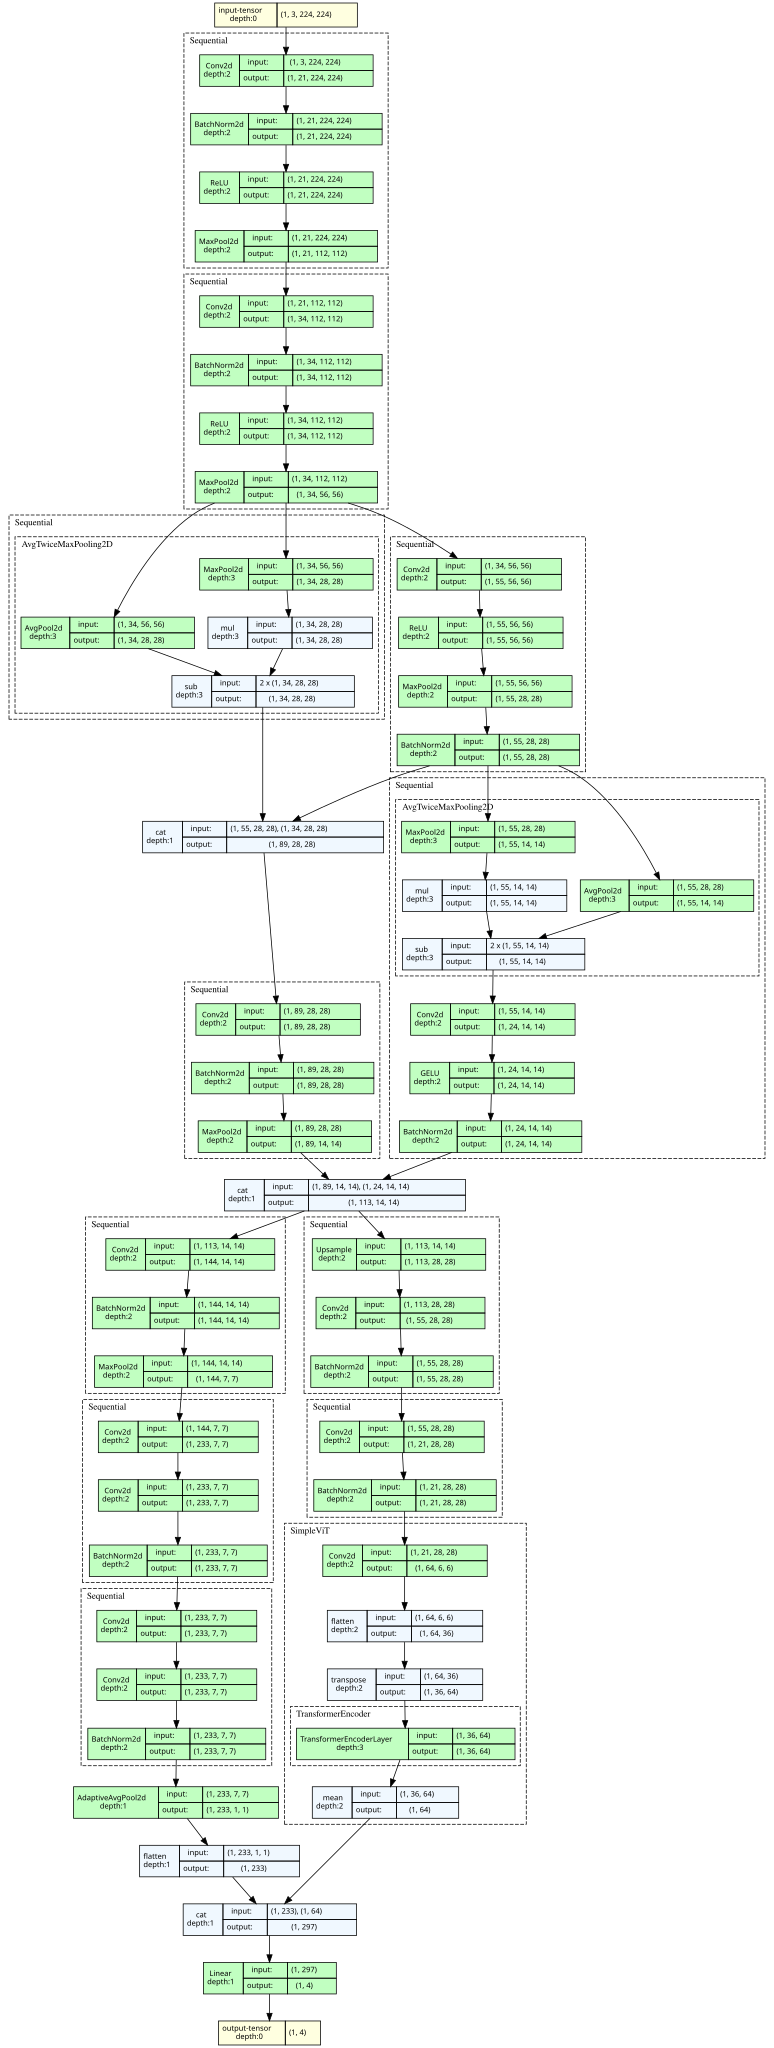

In [24]:


!pip install -q torchview graphviz
from torchview import draw_graph
from IPython.display import SVG, display

dummy = torch.randn(1, 3, 224, 224).to(device)

graph = draw_graph(
    model,
    input_data=dummy,
    expand_nested=True,
    graph_name="MRINet",
    save_graph=False
)

display(SVG(graph.visual_graph.pipe(format="svg")))


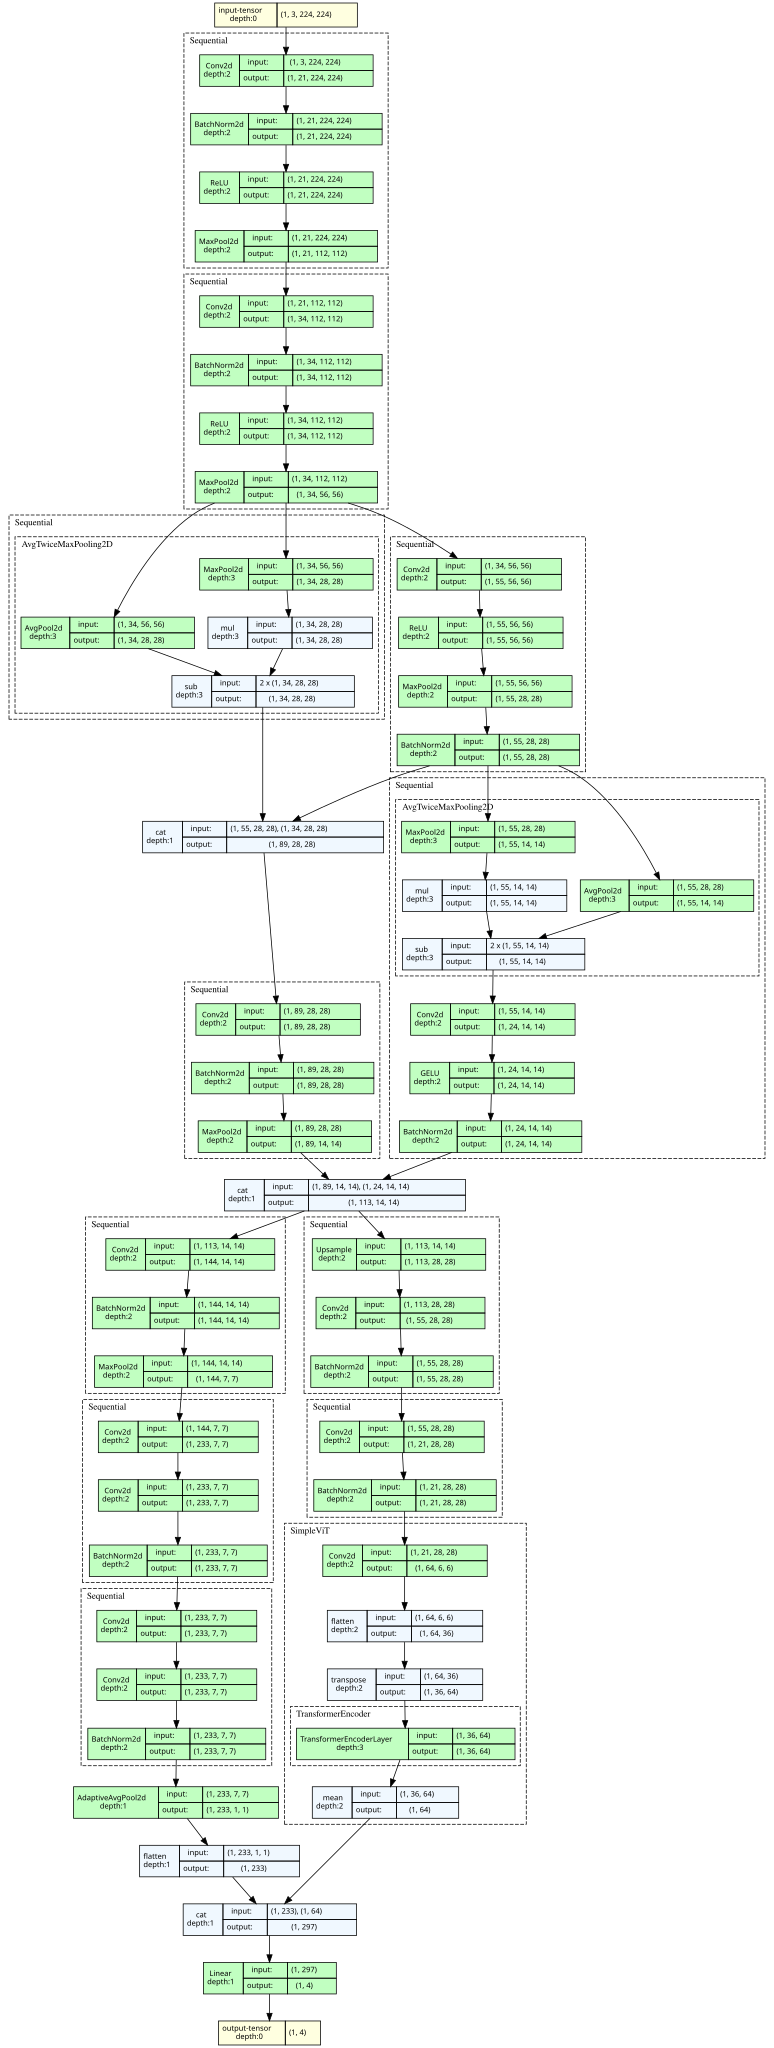

In [25]:
from torchview import draw_graph
from IPython.display import SVG, display

dummy_input = torch.randn(1, 3, 224, 224).to(device)

graph = draw_graph(
    model,
    input_data=dummy_input,
    expand_nested=True,
    graph_name="MRINet",
    save_graph=True,              # IMPORTANT
    filename="MRINet_BlockDiagram",
    directory="."
)

# Display inline
svg = graph.visual_graph.pipe(format="svg")
display(SVG(svg))


In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BWCCE(nn.Module):
    def __init__(self, class_counts):
        """
        class_counts: list or tensor containing the number of samples
                      in each class in label order
        """
        super().__init__()

        class_counts = torch.tensor(class_counts, dtype=torch.float32)

        K = len(class_counts)
        N = class_counts.sum()

        # β_c = 1/(K-1) * (1 - n_c / N)
        class_weights = (1.0 / (K - 1)) * (1.0 - class_counts / N)

        # Register as buffer so it moves automatically with model.to(device)
        self.register_buffer("class_weights", class_weights)

    def forward(self, outputs, targets):

        # Move weights to the same device as the outputs
        weights = self.class_weights.to(outputs.device)

        # Softmax probabilities
        probs = F.softmax(outputs, dim=1)
        probs = torch.clamp(probs, min=1e-7)

        # One-hot encode targets
        targets_onehot = F.one_hot(
            targets,
            num_classes=outputs.size(1)
        ).float()

        # Balanced Weighted Categorical Cross Entropy
        loss = -weights.unsqueeze(0) * targets_onehot * torch.log(probs)

        # Sum over classes
        loss = loss.sum(dim=1)

        # Mean over batch
        return loss.mean()

In [27]:
import torch

# Count samples per class in the TRAIN set
class_counts = torch.tensor(
    train_df["label"]
    .value_counts()
    .sort_index()
    .values,
    dtype=torch.float32
)

K = len(class_counts)      # Number of classes (44)
N = class_counts.sum()     # Total training samples

# Class weights
class_weights = (1.0 / (K - 1)) * (1.0 - class_counts / N)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_weights = class_weights.to(device)

print("Class Counts:\n", class_counts)
print("Class Weights:\n", class_weights)
print("Sum =", class_weights.sum())

Class Counts:
 tensor([741., 749., 721., 400.])
Class Weights:
 tensor([0.2387, 0.2377, 0.2413, 0.2823], device='cuda:0')
Sum = tensor(1., device='cuda:0')


In [28]:
import torch

# Compute class counts from the training set
class_counts = (
    train_df["label"]
    .value_counts()
    .sort_index()
    .tolist()
)

criterion = BWCCE(
    class_counts=class_counts
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=5e-4
)
# Fixed LR for first 15 epochs
warmup_scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=lambda epoch: 1.0
)

adaptive_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)



In [29]:

train_metrics = {
    "acc": MulticlassAccuracy(num_classes=num_classes).to(device),
    "precision": MulticlassPrecision(num_classes=num_classes, average="macro").to(device),
    "recall": MulticlassRecall(num_classes=num_classes, average="macro").to(device),
    "f1": MulticlassF1Score(num_classes=num_classes, average="macro").to(device),
    "auc": MulticlassAUROC(num_classes=num_classes).to(device),
    "mcc": MulticlassMatthewsCorrCoef(num_classes=num_classes).to(device)
}

val_metrics = {
    "acc": MulticlassAccuracy(num_classes=num_classes).to(device),
    "precision": MulticlassPrecision(num_classes=num_classes, average="macro").to(device),
    "recall": MulticlassRecall(num_classes=num_classes, average="macro").to(device),
    "f1": MulticlassF1Score(num_classes=num_classes, average="macro").to(device),
    "auc": MulticlassAUROC(num_classes=num_classes).to(device),
    "mcc": MulticlassMatthewsCorrCoef(num_classes=num_classes).to(device)
}

history = {
    "loss": [], "val_loss": [],
    "accuracy": [], "val_accuracy": [],
    "precision": [], "val_precision": [],
    "recall": [], "val_recall": [],
    "f1": [], "val_f1": [],
    "auc": [], "val_auc": [],
    "mcc": [], "val_mcc": [],
    "specificity": [], "val_specificity": [],
    "sensitivity": [], "val_sensitivity": []
}


In [30]:
import numpy as np
from sklearn.metrics import confusion_matrix

def multiclass_specificity_sensitivity(y_true, y_pred, num_classes):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))

    specificity = []
    sensitivity = []

    for i in range(num_classes):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - (tp + fp + fn)

        specificity.append(tn / (tn + fp + 1e-8))
        sensitivity.append(tp / (tp + fn + 1e-8))

    return float(np.mean(specificity)), float(np.mean(sensitivity))


In [31]:

!pip install -q thop

from thop import profile
import torch

model.eval()

dummy_input = torch.randn(1, 3, 224, 224).to(next(model.parameters()).device)

flops, params = profile(model, inputs=(dummy_input,), verbose=False)

print("=" * 50)
print(f"FLOPs      : {flops:,.0f}")
print(f"GFLOPs     : {flops / 1e9:.4f}")
print(f"Parameters : {params:,.0f}")
print(f"Params (M) : {params / 1e6:.4f} Million")
print("=" * 50)

FLOPs      : 352,146,181
GFLOPs     : 0.3521
Parameters : 1,440,089
Params (M) : 1.4401 Million


In [32]:
EPOCHS = 40

for epoch in range(EPOCHS):

    # ================= TRAIN =================
    model.train()
    train_loss = 0.0
    train_preds, train_targets = [], []

    pbar = tqdm(
        train_loader,
        desc=f"Training Model - Epoch [{epoch+1}/{EPOCHS}]",
        leave=True
    )

    for x, y in pbar:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = out.argmax(dim=1)
        train_preds.append(preds.cpu())
        train_targets.append(y.cpu())

        for m in train_metrics.values():
            m.update(out, y)


    train_preds = torch.cat(train_preds).numpy()
    train_targets = torch.cat(train_targets).numpy()

    train_spec, train_sens = multiclass_specificity_sensitivity(
        train_targets, train_preds, num_classes
    )

    train_out = {k: v.compute().item() for k, v in train_metrics.items()}

    print(
        f"Metrics - loss: {train_loss/len(train_loader):.4f}, "
        f"accuracy: {train_out['acc']:.4f}, "
        f"precision: {train_out['precision']:.4f}, "
        f"recall: {train_out['recall']:.4f}, "
        f"f1_score: {train_out['f1']:.4f}, "
        f"specificity: {train_spec:.4f}, "
        f"sensitivity: {train_sens:.4f}, "
        f"mcc: {train_out['mcc']:.4f}, "
        f"auc: {train_out['auc']:.4f}"
    )
# ===== STORE TRAIN HISTORY =====
    history["loss"].append(train_loss / len(train_loader))
    history["accuracy"].append(train_out["acc"])
    history["precision"].append(train_out["precision"])
    history["recall"].append(train_out["recall"])
    history["f1"].append(train_out["f1"])
    history["auc"].append(train_out["auc"])
    history["mcc"].append(train_out["mcc"])
    history["specificity"].append(train_spec)
    history["sensitivity"].append(train_sens)

    for m in train_metrics.values():
        m.reset()

    # ================= VALID =================
    model.eval()
    val_loss = 0.0
    val_preds, val_targets = [], []

    pbar = tqdm(val_loader, desc="Validating Model", leave=True)

    with torch.no_grad():
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)

            val_loss += loss.item()
            preds = out.argmax(dim=1)

            val_preds.append(preds.cpu())
            val_targets.append(y.cpu())

            for m in val_metrics.values():
                m.update(out, y)

    val_preds = torch.cat(val_preds).numpy()
    val_targets = torch.cat(val_targets).numpy()

    val_spec, val_sens = multiclass_specificity_sensitivity(
        val_targets, val_preds, num_classes
    )

    val_out = {k: v.compute().item() for k, v in val_metrics.items()}
    # ================= SCHEDULER STEP =================
    if epoch < 15:
        warmup_scheduler.step()
    else:
        adaptive_scheduler.step(val_loss / len(val_loader))

    # Optional: print LR
    current_lr = optimizer.param_groups[0]["lr"]
    print(f"Current LR: {current_lr:.6e}")

    print(
        f"Metrics - loss: {val_loss/len(val_loader):.4f}, "
        f"accuracy: {val_out['acc']:.4f}, "
        f"precision: {val_out['precision']:.4f}, "
        f"recall: {val_out['recall']:.4f}, "
        f"f1_score: {val_out['f1']:.4f}, "
        f"specificity: {val_spec:.4f}, "
        f"sensitivity: {val_sens:.4f}, "
        f"mcc: {val_out['mcc']:.4f}, "
        f"auc: {val_out['auc']:.4f}"
    )
    # ===== STORE VALID HISTORY =====
    history["val_loss"].append(val_loss / len(val_loader))
    history["val_accuracy"].append(val_out["acc"])
    history["val_precision"].append(val_out["precision"])
    history["val_recall"].append(val_out["recall"])
    history["val_f1"].append(val_out["f1"])
    history["val_auc"].append(val_out["auc"])
    history["val_mcc"].append(val_out["mcc"])
    history["val_specificity"].append(val_spec)
    history["val_sensitivity"].append(val_sens)


    for m in val_metrics.values():
        m.reset()


Training Model - Epoch [1/40]: 100%|██████████| 327/327 [00:27<00:00, 12.01it/s]


Metrics - loss: 0.2404, accuracy: 0.6033, precision: 0.6031, recall: 0.6033, f1_score: 0.6020, specificity: 0.8656, sensitivity: 0.6033, mcc: 0.4653, auc: 0.8266


Validating Model: 100%|██████████| 41/41 [00:01<00:00, 30.74it/s]


Current LR: 5.000000e-04
Metrics - loss: 0.1841, accuracy: 0.7624, precision: 0.7510, recall: 0.7624, f1_score: 0.7547, specificity: 0.9175, sensitivity: 0.7624, mcc: 0.6697, auc: 0.9107


Training Model - Epoch [2/40]: 100%|██████████| 327/327 [00:15<00:00, 21.62it/s]


...

Current LR: 1.562500e-05
Metrics - loss: 0.0731, accuracy: 0.9247, precision: 0.9150, recall: 0.9247, f1_score: 0.9183, specificity: 0.9723, sensitivity: 0.9247, mcc: 0.8889, auc: 0.9921


Training Model - Epoch [40/40]: 100%|██████████| 327/327 [00:17<00:00, 18.46it/s]


Metrics - loss: 0.0013, accuracy: 1.0000, precision: 1.0000, recall: 1.0000, f1_score: 1.0000, specificity: 1.0000, sensitivity: 1.0000, mcc: 1.0000, auc: 1.0000


Validating Model: 100%|██████████| 41/41 [00:02<00:00, 19.43it/s]

Current LR: 1.562500e-05
Metrics - loss: 0.0797, accuracy: 0.9225, precision: 0.9141, recall: 0.9225, f1_score: 0.9170, specificity: 0.9723, sensitivity: 0.9225, mcc: 0.8888, auc: 0.9922


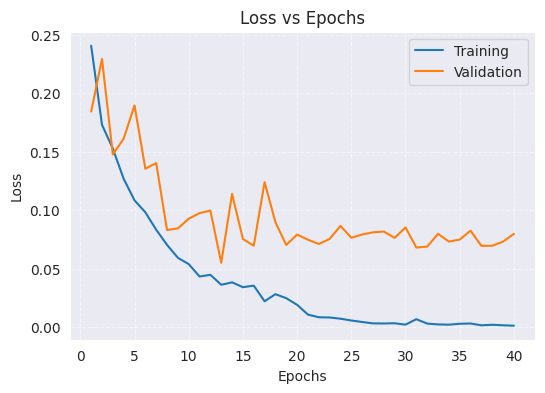

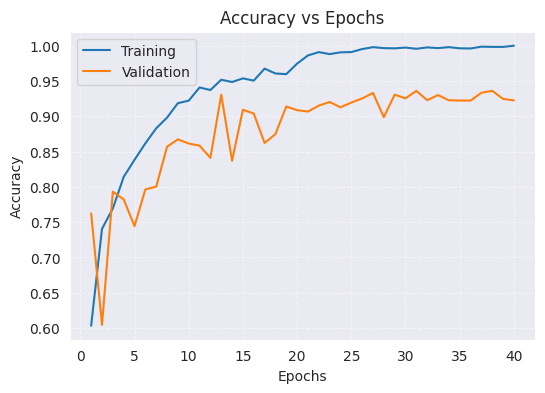

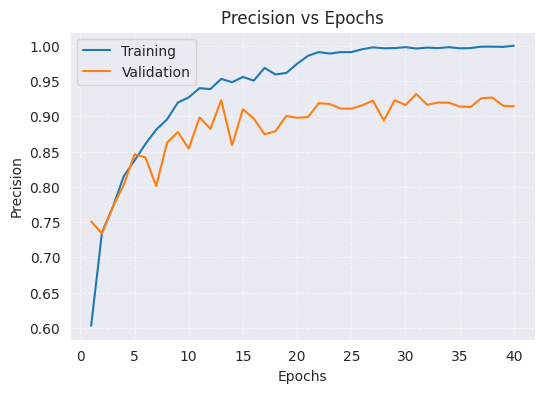

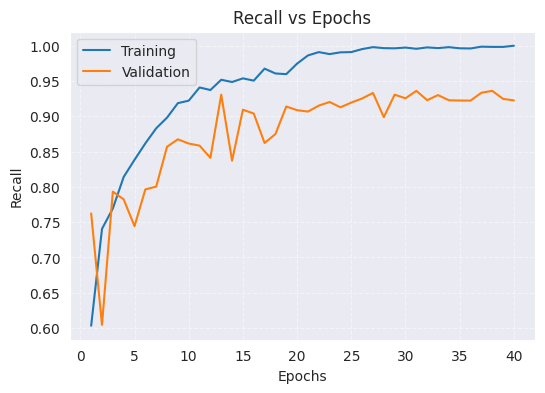

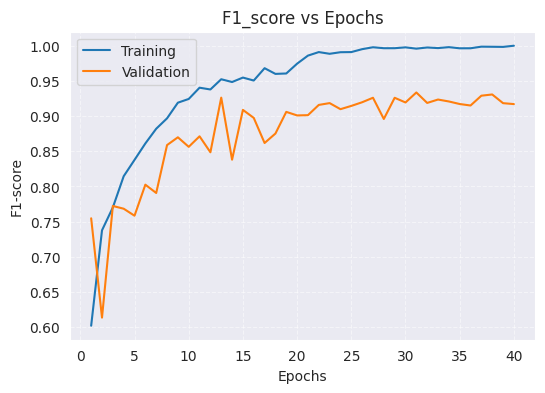

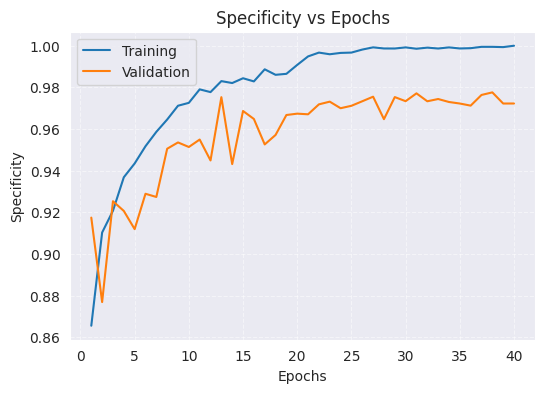

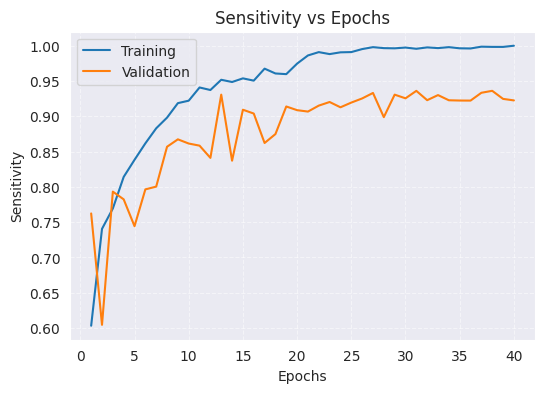

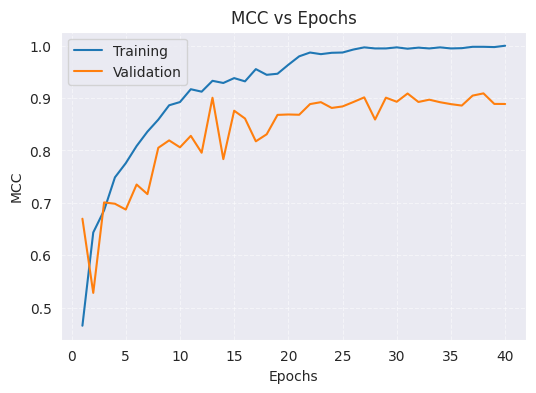

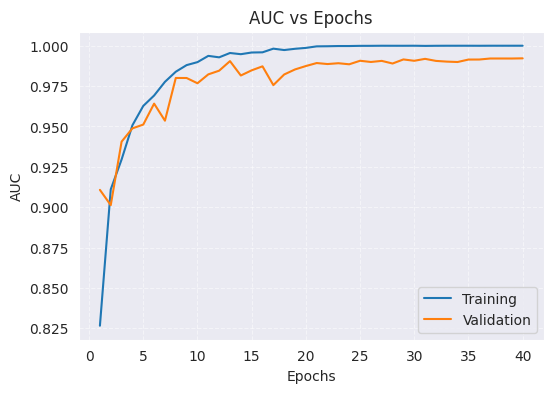

In [33]:
def plot_metric(train, val, title, ylabel):
    epochs = range(1, len(train) + 1)
    plt.figure(figsize=(6, 4))
    plt.plot(epochs, train, label="Training")
    plt.plot(epochs, val, label="Validation")
    plt.title(title)
    plt.xlabel("Epochs")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()


plot_metric(history["loss"], history["val_loss"], "Loss vs Epochs", "Loss")
plot_metric(history["accuracy"], history["val_accuracy"], "Accuracy vs Epochs", "Accuracy")
plot_metric(history["precision"], history["val_precision"], "Precision vs Epochs", "Precision")
plot_metric(history["recall"], history["val_recall"], "Recall vs Epochs", "Recall")
plot_metric(history["f1"], history["val_f1"], "F1_score vs Epochs", "F1-score")
plot_metric(history["specificity"], history["val_specificity"], "Specificity vs Epochs", "Specificity")
plot_metric(history["sensitivity"], history["val_sensitivity"], "Sensitivity vs Epochs", "Sensitivity")
plot_metric(history["mcc"], history["val_mcc"], "MCC vs Epochs", "MCC")
plot_metric(history["auc"], history["val_auc"], "AUC vs Epochs", "AUC")


In [34]:
model.eval()
test_metrics = {k: v.clone().to(device) for k, v in train_metrics.items()}
test_loss = 0.0
all_preds, all_targets = [], []

with torch.no_grad():
    pbar = tqdm(test_loader, desc="Testing Model")
    for x, y in pbar:
        x, y = x.to(device), y.to(device)
        out = model(x)
        loss = criterion(out, y)
        test_loss += loss.item()

        preds = out.argmax(dim=1)
        all_preds.append(preds.cpu())
        all_targets.append(y.cpu())

        for m in test_metrics.values():
            m.update(out, y)

all_preds = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()

test_spec, test_sens = multiclass_specificity_sensitivity(
    all_targets, all_preds, num_classes
)

print(
    f"Metrics - loss: {test_loss/len(test_loader):.4f}, "
    f"accuracy: {test_metrics['acc'].compute().item():.4f}, "
    f"precision: {test_metrics['precision'].compute().item():.4f}, "
    f"recall: {test_metrics['recall'].compute().item():.4f}, "
    f"f1_score: {test_metrics['f1'].compute().item():.4f}, "
    f"specificity: {test_spec:.4f}, "
    f"sensitivity: {test_sens:.4f}, "
    f"mcc: {test_metrics['mcc'].compute().item():.4f}, "
    f"auc: {test_metrics['auc'].compute().item():.4f}"
)


Testing Model: 100%|██████████| 41/41 [00:03<00:00, 12.57it/s]

Metrics - loss: 0.0977, accuracy: 0.9281, precision: 0.9201, recall: 0.9281, f1_score: 0.9235, specificity: 0.9744, sensitivity: 0.9281, mcc: 0.8969, auc: 0.9861


Class names: ['glioma', 'meningioma', 'pituitary', 'notumor']

Classification Report (Test Set):

              precision    recall  f1-score   support

      glioma     0.9341    0.9140    0.9239        93
  meningioma     0.9326    0.8830    0.9071        94
   pituitary     0.9247    0.9556    0.9399        90
     notumor     0.8889    0.9600    0.9231        50

    accuracy                         0.9235       327
   macro avg     0.9201    0.9281    0.9235       327
weighted avg     0.9242    0.9235    0.9234       327



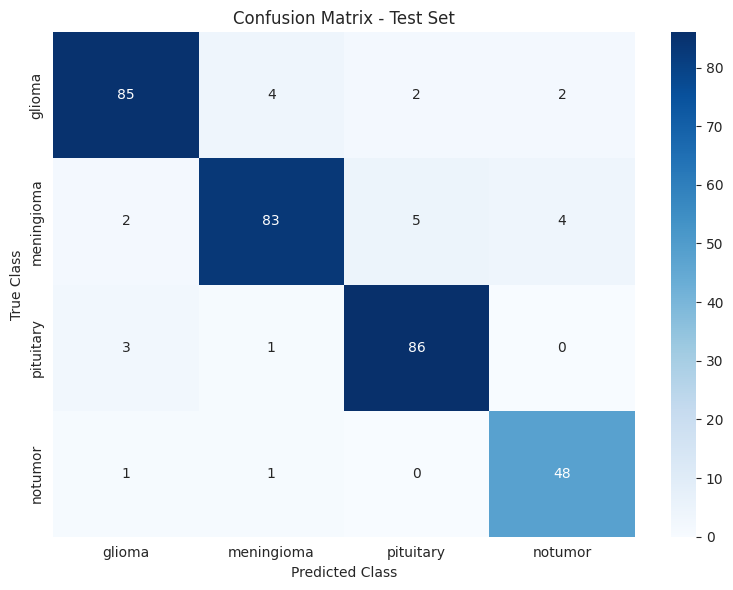

In [36]:

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# CLASS NAMES
# ============================================================

# Existing mapping in your notebook:
# label_map = {
#     "glioma": 0,
#     "meningioma": 1,
#     "pituitary": 2,
#     "notumor": 3
# }

# Convert label_map into index -> class name
idx_to_class = {v: k for k, v in label_map.items()}

class_names = [idx_to_class[i] for i in range(num_classes)]

print("Class names:", class_names)


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report (Test Set):\n")

report = classification_report(
    all_targets,
    all_preds,
    labels=list(range(num_classes)),
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(report)


# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    all_targets,
    all_preds,
    labels=list(range(num_classes))
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix - Test Set")

plt.tight_layout()
plt.show()


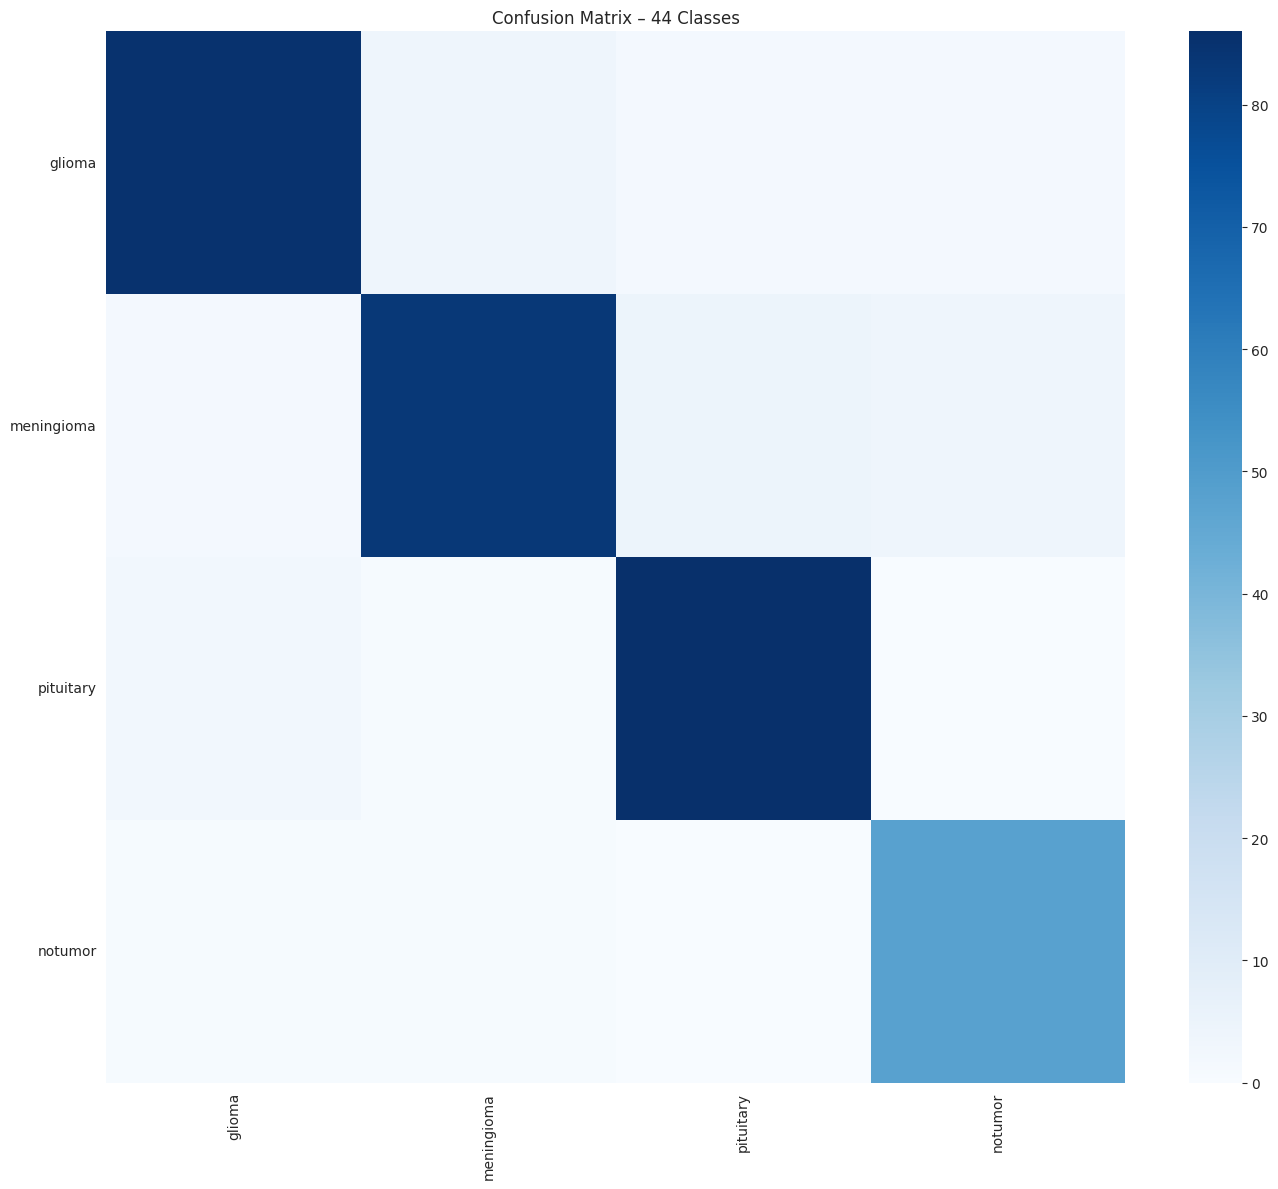

In [37]:
cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title("Confusion Matrix – 44 Classes")
plt.tight_layout()
plt.show()
